<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/03_construction_eda_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DADS5001 Mini Project
## EDA โครงการจ้างก่อสร้างภายใต้เกณฑ์วงเงิน 500,000 บาท

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

Notebook นี้ใช้โครงการจ้างก่อสร้างทั้งหมดเป็นประชากรอ้างอิง เพื่ออธิบายโครงสร้างของวงเงินและวิธีจัดซื้อ จากนั้นจำกัดกลุ่มศึกษาหลักเป็น **โครงการจ้างก่อสร้างโดยวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาท**

### คำถาม

1. ขนาดโครงการสัมพันธ์กับวิธีจัดซื้ออย่างไร
2. เหตุใดวงเงิน 500,000 บาทจึงเป็นเส้นแบ่งที่ควรศึกษา
3. วงเงินกระจุกอยู่บริเวณใต้เส้นแบ่งหรือไม่
4. ราคาที่ตกลงสัมพันธ์กับงบประมาณและราคากลางอย่างไร
5. รูปแบบใดควรส่งต่อไปสร้างตัวชี้วัดใน Notebook 04

> ผลการวิเคราะห์ใช้จัดลำดับการเปิดเอกสารตรวจสอบ ไม่ใช่หลักฐานว่ามีการกระทำผิด


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

# ดาวน์โหลดฟอนต์ TH Sarabun New
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# เพิ่มฟอนต์ให้ Matplotlib
fm.fontManager.addfont(
    'thsarabunnew-webfont.ttf'
)

# กำหนดฟอนต์เริ่มต้นสำหรับ Matplotlib และ Seaborn
mpl.rc(
    'font',
    family='TH Sarabun New'
)
mpl.rcParams['axes.unicode_minus'] = False

sns.set_theme(
    style='whitegrid',
    font='TH Sarabun New'
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option(
    'display.float_format',
    lambda value: f'{value:,.2f}'
)

data_path = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/egp-contract/'
    'processed/construction_contracts_2569.csv'
)

project_directory = data_path.parents[4]
figure_directory = project_directory / 'figure'
figure_directory.mkdir(parents=True, exist_ok=True)

construction_data = pd.read_csv(
    data_path,
    low_memory=False
)

print(f'Shape: {construction_data.shape}')
print(f'Figure directory: {figure_directory}')


Shape: (180079, 29)
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


## 1. ทำความเข้าใจข้อมูล

เริ่มจากตรวจสอบโครงสร้าง ชนิดข้อมูล ค่าว่าง และจำนวนค่าที่ไม่ซ้ำ
ของแต่ละคอลัมน์ เพื่อเลือกตัวแปรที่สามารถนำมาใช้วิเคราะห์ได้จริง

การตรวจในส่วนนี้มุ่งเฉพาะข้อมูลที่จำเป็นต่อ EDA
ไม่ใช่การตรวจสอบคุณภาพข้อมูลอย่างละเอียด

In [3]:
display(construction_data.head())

,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแพทย์โรงพยาบาลกลางและอาคารสำนักการแพทย์ ด้วยวิธีประ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ้าอากาศเป็นสายไฟฟ้าใต้ดิน โครงการตามแนวรถไฟฟ้าสายส...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.64957141876 13.762728849181,100.74447870255 13.8163...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเร็งแห่งชาติแห่งใหม่ (สาขาบางขุนเทียน) สถาบันมะเร็ง...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,6 ม.ค. 69,"3,300,000,000.00","3,407,005,257.46","3,285,000,000.00",2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.41980266571 13.569885753428,100.42091846466 13.5711...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ้าอากาศเป็นสายไฟฟ้าใต้ดิน โครงการตามแนวรถไฟฟ้าสายส...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,28 พ.ย. 68,"3,370,500,000.00","3,285,232,000.00","3,282,800,000.00",2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100.60111999512 13.882745613918,100.60111999512 13.88...",13.88,100.60,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงขยาย การประปาส่วนภูมิภาคสาขาพังงา-ภูเก็ต ระยะที่ 1 ...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพาะเจาะจง,16 ก.ค. 68,"3,498,760,900.00","3,498,752,340.00","3,250,900,000.00",2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.43,98.53,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [4]:
field_summary = pd.DataFrame({
    'column': construction_data.columns,
    'dtype': (
        construction_data
        .dtypes
        .astype(str)
        .values
    ),
    'non_null': (
        construction_data
        .notna()
        .sum()
        .values
    ),
    'missing': (
        construction_data
        .isna()
        .sum()
        .values
    ),
    'missing_pct': (
        construction_data
        .isna()
        .mean()
        .mul(100)
        .values
    ),
    'unique': (
        construction_data
        .nunique(
            dropna=True
        )
        .values
    )
})

display(field_summary)

,column,dtype,non_null,missing,missing_pct,unique
0,ลำดับ,int64,180079,0,0.00,180079
1,รหัสโครงการ,int64,180079,0,0.00,178978
2,ชื่อโครงการจัดซื้อจัดจ้าง,object,180079,0,0.00,175978
3,ชื่อประเภทโครงการ,object,180079,0,0.00,1
4,ชื่อหน่วยงาน,object,180079,0,0.00,15553
5,ชื่อหน่วยงานย่อย,object,180078,1,0.00,20531
6,ชื่อวิธีการจัดซื้อจัดจ้าง,object,180079,0,0.00,4
7,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,object,180079,0,0.00,1
8,วันที่ประกาศจัดซื้อจัดจ้าง,object,180079,0,0.00,349
9,วงเงินงบประมาณ (บาท),float64,180079,0,0.00,32156


### สรุปการทำความเข้าใจข้อมูล

ข้อมูลจ้างก่อสร้างมี 180,079 แถว และ 29 คอลัมน์
ตัวแปรหลักด้านงบประมาณ ราคา วิธีจัดซื้อ หน่วยงาน และพื้นที่
มีข้อมูลค่อนข้างครบถ้วน

คอลัมน์ `ราคากลาง (บาท)` ขาดข้อมูล 107 แถว หรือ 0.06%
และ `วงเงินงบประมาณในสัญญา (บาท)` ขาดข้อมูล 90 แถว
หรือ 0.05% ส่วนข้อมูลพิกัดขาด 1,438 แถว หรือ 0.80%

คอลัมน์ต่อไปนี้มีเพียงค่าเดียว จึงไม่ช่วยในการเปรียบเทียบ
ภายในชุดข้อมูลจ้างก่อสร้าง:

- ชื่อประเภทโครงการ
- ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง
- ปีงบประมาณ
- สถานะโครงการ
- สถานะสัญญา

ก่อนสร้างข้อมูลระดับโครงการ จะตรวจสอบว่าแถวที่ใช้
`รหัสโครงการ` เดียวกันมีค่าของตัวแปรระดับโครงการ
สอดคล้องกันหรือไม่

In [5]:
project_columns = [
    'ชื่อโครงการจัดซื้อจัดจ้าง',
    'ชื่อหน่วยงาน',
    'ชื่อหน่วยงานย่อย',
    'ชื่อวิธีการจัดซื้อจัดจ้าง',
    'วันที่ประกาศจัดซื้อจัดจ้าง',
    'วงเงินงบประมาณ (บาท)',
    'ราคากลาง (บาท)',
    (
        'ราคาที่ตกลงซื้อ / จ้าง '
        'ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
    ),
    'วันที่เกิดรายการ',
    'จังหวัด',
    'เขต/อำเภอ',
    'แขวง/ตำบล'
]

project_consistency = (
    construction_data
    .groupby('รหัสโครงการ')[
        project_columns
    ]
    .nunique(
        dropna=False
    )
)

inconsistent_projects = (
    project_consistency
    .gt(1)
    .sum()
    .rename(
        'projects_with_multiple_values'
    )
    .to_frame()
)

display(inconsistent_projects)

,projects_with_multiple_values
ชื่อโครงการจัดซื้อจัดจ้าง,0
ชื่อหน่วยงาน,0
ชื่อหน่วยงานย่อย,0
ชื่อวิธีการจัดซื้อจัดจ้าง,0
วันที่ประกาศจัดซื้อจัดจ้าง,0
วงเงินงบประมาณ (บาท),0
ราคากลาง (บาท),0
ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),0
วันที่เกิดรายการ,0
จังหวัด,0


## 2. เตรียมข้อมูลระดับโครงการ

จากการตรวจสอบโครงการที่ปรากฏมากกว่าหนึ่งแถว พบว่าตัวแปร
ระดับโครงการทั้งหมดมีค่าตรงกันภายใน `รหัสโครงการ` เดียวกัน
ได้แก่ ชื่อโครงการ หน่วยงาน วิธีจัดซื้อ วันที่ ราคา และพื้นที่

ดังนั้น สามารถสร้างชุดข้อมูลระดับโครงการโดยเก็บหนึ่งแถวต่อ
`รหัสโครงการ` ได้ โดยไม่ทำให้ข้อมูลระดับโครงการสูญหาย

ชุดข้อมูลที่ใช้ต่อจากนี้แบ่งเป็น:

- `project_data` สำหรับวิเคราะห์จำนวนโครงการ ราคา หน่วยงาน
  วิธีจัดซื้อ และพื้นที่
- `construction_data` สำหรับวิเคราะห์ผู้ชนะและรายละเอียดสัญญา

In [6]:
project_data = (
    construction_data
    .drop_duplicates(
        subset='รหัสโครงการ',
        keep='first'
    )
    .copy()
)

print(
    f'Contract-level rows: '
    f'{len(construction_data):,}'
)

print(
    f'Project-level rows: '
    f'{len(project_data):,}'
)

print(
    f'Rows removed from project-level analysis: '
    f'{len(construction_data) - len(project_data):,}'
)

Contract-level rows: 180,079
Project-level rows: 178,978
Rows removed from project-level analysis: 1,101


In [7]:
money_columns = [
    'วงเงินงบประมาณ (บาท)',
    'ราคากลาง (บาท)',
    (
        'ราคาที่ตกลงซื้อ / จ้าง '
        'ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
    )
]

money_summary = (
    project_data[
        money_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

display(money_summary)

non_positive_summary = pd.DataFrame({
    'column': money_columns,
    'zero_or_negative': [
        project_data[column]
        .le(0)
        .sum()
        for column in money_columns
    ],
    'missing': [
        project_data[column]
        .isna()
        .sum()
        for column in money_columns
    ]
})

display(non_positive_summary)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
วงเงินงบประมาณ (บาท),"178,978.00","2,659,155.23","30,273,037.92",900.00,"18,800.00","181,100.00","395,000.00","500,000.00","9,751,915.00","32,500,000.00","4,083,120,000.00"
ราคากลาง (บาท),"178,873.00","2,671,355.48","30,473,922.55",1.00,"18,226.29","180,000.00","391,600.00","523,945.36","9,579,469.90","32,852,727.31","4,000,000,000.00"
ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),"178,978.00","2,518,057.32","29,325,621.96",900.00,"18,000.00","176,000.00","381,000.00","499,000.00","9,096,204.80","30,914,950.00","3,997,800,000.00"


,column,zero_or_negative,missing
0,วงเงินงบประมาณ (บาท),0,0
1,ราคากลาง (บาท),0,105
2,ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),0,0


### สรุปตัวแปรด้านการเงิน

วงเงินงบประมาณมีค่ามัธยฐาน 395,000 บาท แต่มีค่าเฉลี่ย 2.66 ล้านบาท เพราะโครงการมูลค่าสูงจำนวนน้อยลากค่าเฉลี่ยขึ้น

ความเบ้ขวาจึงบอกว่า “โครงการทั่วไป” มีขนาดเล็กกว่าที่ค่าเฉลี่ยสื่อ และจำนวนโครงการกับวงเงินรวมอาจให้ภาพต่างกัน ส่วนถัดไปจึงรายงานทั้งสองมิติ


In [8]:
budget_column = 'วงเงินงบประมาณ (บาท)'
reference_price_column = 'ราคากลาง (บาท)'

awarded_price_column = (
    'ราคาที่ตกลงซื้อ / จ้าง '
    'ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
)

# Positive value means the awarded price is below the budget
project_data['budget_saving'] = (
    project_data[budget_column]
    - project_data[awarded_price_column]
)

project_data['budget_saving_pct'] = (
    project_data['budget_saving']
    .div(project_data[budget_column])
    .mul(100)
)

# Positive value means the awarded price is below the reference price
project_data['reference_discount'] = (
    project_data[reference_price_column]
    - project_data[awarded_price_column]
)

project_data['reference_discount_pct'] = (
    project_data['reference_discount']
    .div(
        project_data[
            reference_price_column
        ]
    )
    .mul(100)
)

In [9]:
price_difference_columns = [
    'budget_saving',
    'budget_saving_pct',
    'reference_discount',
    'reference_discount_pct'
]

display(
    project_data[
        price_difference_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

price_relationship_summary = pd.DataFrame({
    'comparison': [
        'Awarded price below budget',
        'Awarded price equal to budget',
        'Awarded price above budget',
        'Awarded price below reference price',
        'Awarded price equal to reference price',
        'Awarded price above reference price'
    ],
    'project_count': [
        project_data['budget_saving'].gt(0).sum(),
        project_data['budget_saving'].eq(0).sum(),
        project_data['budget_saving'].lt(0).sum(),
        project_data['reference_discount'].gt(0).sum(),
        project_data['reference_discount'].eq(0).sum(),
        project_data['reference_discount'].lt(0).sum()
    ]
})

price_relationship_summary['project_pct'] = (
    price_relationship_summary['project_count']
    .div(len(project_data))
    .mul(100)
)

display(price_relationship_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
budget_saving,"178,978.00","141,097.91","2,041,890.77","-46,720,000.00",0.00,0.00,0.00,"1,000.00","17,200.00","587,000.00","2,187,230.00","428,381,000.00"
budget_saving_pct,"178,978.00",4.14,11.01,"-1,316.67",0.00,0.00,0.00,0.32,3.27,24.74,41.20,98.62
reference_discount,"178,873.00","152,387.50","6,295,837.06","-47,723,300.00",0.00,0.00,55.73,"1,222.76","15,843.27","518,489.45","2,019,057.66","2,302,801,200.00"
reference_discount_pct,"178,873.00",-57.56,"24,595.52","-10,399,900.00",0.00,0.00,0.02,0.34,3.23,23.87,38.24,99.91


,comparison,project_count,project_pct
0,Awarded price below budget,120659,67.42
1,Awarded price equal to budget,58003,32.41
2,Awarded price above budget,316,0.18
3,Awarded price below reference price,139262,77.81
4,Awarded price equal to reference price,38816,21.69
5,Awarded price above reference price,795,0.44


### การตรวจความสัมพันธ์ของราคาเบื้องต้น

ในโครงการก่อสร้างทั้งหมด ราคาที่ตกลงต่ำกว่างบประมาณ 67.42% เท่ากับงบประมาณ 32.41% และสูงกว่า 0.18% ส่วนการเทียบราคากลางใช้เป็นการตรวจเบื้องต้น เพราะยังมีราคากลางที่ขาดหายหรือผิดสัดส่วน

ผลส่วนนี้ใช้ตรวจโครงสร้างข้อมูลเท่านั้น การสร้างตัวชี้วัดราคาจะจำกัดให้เหลือกลุ่มศึกษาหลักและราคากลางที่ใช้งานได้


## 3. การวิเคราะห์เชิงสำรวจ

### 3.1 จำนวนโครงการและวงเงินกระจายเหมือนกันหรือไม่

เริ่มจากโครงการก่อสร้างทั้งหมด เพื่อเปรียบเทียบสัดส่วนจำนวนโครงการกับสัดส่วนวงเงินรวมในแต่ละช่วง ก่อนกำหนดกลุ่มศึกษาหลัก


In [10]:
project_data['budget_million'] = (
    project_data[budget_column]
    .div(1_000_000)
)

project_data['log10_budget'] = np.log10(
    project_data[budget_column]
)

budget_p99 = (
    project_data['budget_million']
    .quantile(0.99)
)

print(
    f'99th percentile of budget: '
    f'{budget_p99:,.2f} million THB'
)

99th percentile of budget: 32.50 million THB


In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=project_data,
    x='budget_million',
    bins=50,
    ax=axes[0],
    color='#4C78A8'
)

axes[0].set_xlim(0, budget_p99)
axes[0].set_title('การกระจายวงเงินไม่เกินเปอร์เซ็นไทล์ที่ 99')
axes[0].set_xlabel('วงเงินงบประมาณ (ล้านบาท)')
axes[0].set_ylabel('จำนวนโครงการ')

sns.histplot(
    data=project_data,
    x='log10_budget',
    bins=50,
    ax=axes[1],
    color='#E67E22'
)

axes[1].set_title('การกระจายวงเงินบนมาตราส่วนลอการิทึม')
axes[1].set_xlabel('Log10 ของวงเงินงบประมาณ (บาท)')
axes[1].set_ylabel('จำนวนโครงการ')

plt.tight_layout()
plt.show()


In [12]:
common_budget_values = (
    project_data[budget_column]
    .value_counts()
    .head(15)
    .rename_axis('budget')
    .reset_index(name='project_count')
)

common_budget_values['budget_million'] = (
    common_budget_values['budget']
    .div(1_000_000)
)

common_budget_values['project_pct'] = (
    common_budget_values['project_count']
    .div(len(project_data))
    .mul(100)
)

display(
    common_budget_values[
        [
            'budget',
            'budget_million',
            'project_count',
            'project_pct'
        ]
    ]
)

,budget,budget_million,project_count,project_pct
0,"500,000.00",0.50,6523,3.64
1,"499,000.00",0.50,3593,2.01
2,"200,000.00",0.20,2527,1.41
3,"498,000.00",0.50,2438,1.36
4,"300,000.00",0.30,2266,1.27
5,"100,000.00",0.10,1991,1.11
6,"490,000.00",0.49,1790,1.00
7,"150,000.00",0.15,1527,0.85
8,"495,000.00",0.49,1525,0.85
9,"400,000.00",0.40,1481,0.83


### ข้อค้นพบจากการกระจายของวงเงิน

วงเงินกระจายเบ้ขวาและเปอร์เซ็นไทล์ที่ 99 อยู่ที่ 32.50 ล้านบาท ภาพมาตราส่วนลอการิทึมใช้ตรวจรูปทรงการกระจาย ส่วนภาพช่วงงบประมาณด้านล่างใช้สื่อสารข้อค้นพบหลัก


In [13]:
budget_bins = [
    0,
    100_000,
    200_000,
    300_000,
    400_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    np.inf
]

budget_labels = [
    'ไม่เกิน 100,000',
    '100,001–200,000',
    '200,001–300,000',
    '300,001–400,000',
    '400,001–500,000',
    '500,001–1 ล้าน',
    'มากกว่า 1–5 ล้าน',
    'มากกว่า 5–10 ล้าน',
    'มากกว่า 10–50 ล้าน',
    'มากกว่า 50 ล้าน'
]

project_data['budget_band'] = pd.cut(
    project_data[budget_column],
    bins=budget_bins,
    labels=budget_labels,
    include_lowest=True,
    right=True
)

budget_band_summary = (
    project_data
    .groupby('budget_band', observed=False)
    .agg(
        project_count=('รหัสโครงการ', 'size'),
        total_budget=(budget_column, 'sum')
    )
    .reset_index()
)

budget_band_summary['project_pct'] = (
    budget_band_summary['project_count']
    / len(project_data)
    * 100
)

budget_band_summary['budget_pct'] = (
    budget_band_summary['total_budget']
    / budget_band_summary['total_budget'].sum()
    * 100
)

display(budget_band_summary)


,budget_band,project_count,total_budget,project_pct,budget_pct
0,"ไม่เกิน 100,000",23393,"1,391,944,502.51",13.07,0.29
1,"100,001–200,000",27835,"4,244,799,665.13",15.55,0.89
2,"200,001–300,000",22675,"5,754,249,900.83",12.67,1.21
3,"300,001–400,000",17815,"6,284,080,423.64",9.95,1.32
4,"400,001–500,000",44905,"21,508,548,791.78",25.09,4.52
5,"500,001–1 ล้าน",8171,"6,142,652,360.00",4.57,1.29
6,มากกว่า 1–5 ล้าน,18981,"49,057,947,604.33",10.61,10.31
7,มากกว่า 5–10 ล้าน,7899,"61,201,364,790.37",4.41,12.86
8,มากกว่า 10–50 ล้าน,6421,"138,630,828,482.95",3.59,29.13
9,มากกว่า 50 ล้าน,883,"181,713,868,683.13",0.49,38.18


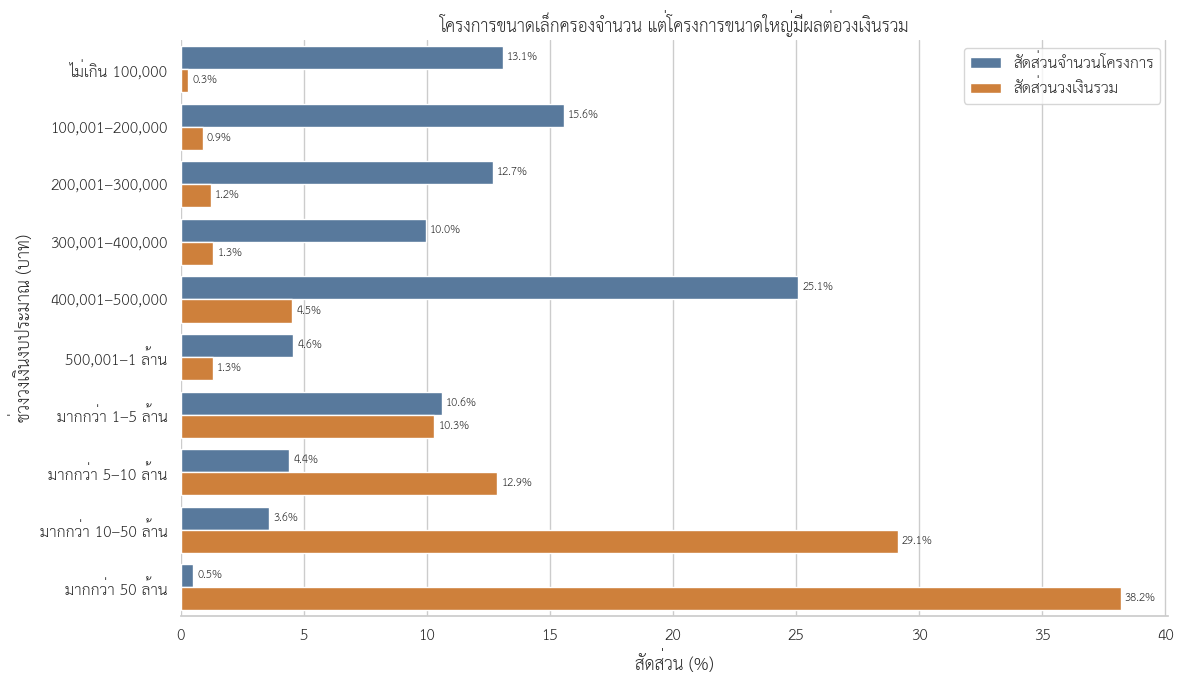

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_project_and_budget_share_by_budget_band.png


In [14]:
budget_band_plot = (
    budget_band_summary[
        ['budget_band', 'project_pct', 'budget_pct']
    ]
    .melt(
        id_vars='budget_band',
        var_name='measure',
        value_name='percentage'
    )
)

budget_band_plot['measure'] = budget_band_plot['measure'].map({
    'project_pct': 'สัดส่วนจำนวนโครงการ',
    'budget_pct': 'สัดส่วนวงเงินรวม'
})

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=budget_band_plot,
    y='budget_band',
    x='percentage',
    hue='measure',
    palette=['#4C78A8', '#E67E22'],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

ax.set_title('โครงการขนาดเล็กครองจำนวน แต่โครงการขนาดใหญ่มีผลต่อวงเงินรวม')
ax.set_xlabel('สัดส่วน (%)')
ax.set_ylabel('ช่วงวงเงินงบประมาณ (บาท)')
ax.legend(title='')
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig03_01_project_and_budget_share_by_budget_band.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Figure saved: {figure_path}')


### ข้อค้นพบ: จำนวนกับวงเงินให้ภาพต่างกัน

โครงการไม่เกิน 500,000 บาทคิดเป็น 76.34% ของจำนวนโครงการ แต่รวมกันเพียง 8.23% ของวงเงินทั้งหมด ขณะที่โครงการมากกว่า 10 ล้านบาทมีเพียง 4.08% ของจำนวน แต่ครองวงเงินรวม 67.31%

ดังนั้นจำนวนโครงการสะท้อนภาระการดำเนินงาน ส่วนวงเงินรวมสะท้อนขนาดทรัพยากร ทั้งสองมิติต้องอ่านคู่กัน


### 3.2 ขนาดโครงการสัมพันธ์กับวิธีจัดซื้ออย่างไร

พระราชบัญญัติการจัดซื้อจัดจ้างฯ มาตรา 55 กำหนดวิธีหลัก ได้แก่ วิธีประกาศเชิญชวนทั่วไป วิธีคัดเลือก และวิธีเฉพาะเจาะจง ส่วนมาตรา 56 วรรคหนึ่ง (2)(ข) ประกอบกฎกระทรวงกำหนดวงเงินฯ กำหนดบริบทของวิธีเฉพาะเจาะจงสำหรับการจัดซื้อจัดจ้างทั่วไปวงเงินไม่เกิน 500,000 บาท

จึงเปรียบเทียบทั้งสัดส่วนจำนวนโครงการและวงเงินรวมตามวิธีจัดซื้อ ก่อนกำหนดประชากรศึกษาหลัก


In [15]:
method_column = (
    'ชื่อวิธีการจัดซื้อจัดจ้าง'
)

method_analysis = (
    project_data
    .assign(
        awarded_above_budget=(
            project_data[
                awarded_price_column
            ]
            .gt(
                project_data[
                    budget_column
                ]
            )
        ),
        awarded_equal_budget=(
            project_data[
                awarded_price_column
            ]
            .eq(
                project_data[
                    budget_column
                ]
            )
        ),
        reference_available=(
            project_data[
                reference_price_column
            ]
            .notna()
        ),
        awarded_above_reference=(
            project_data[
                awarded_price_column
            ]
            .gt(
                project_data[
                    reference_price_column
                ]
            )
        ),
        awarded_equal_reference=(
            project_data[
                awarded_price_column
            ]
            .eq(
                project_data[
                    reference_price_column
                ]
            )
        )
    )
    .groupby(method_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_budget=(
            budget_column,
            'sum'
        ),
        median_budget=(
            budget_column,
            'median'
        ),
        median_budget_saving_pct=(
            'budget_saving_pct',
            'median'
        ),
        median_reference_discount_pct=(
            'reference_discount_pct',
            'median'
        ),
        above_budget_count=(
            'awarded_above_budget',
            'sum'
        ),
        equal_budget_count=(
            'awarded_equal_budget',
            'sum'
        ),
        reference_available_count=(
            'reference_available',
            'sum'
        ),
        above_reference_count=(
            'awarded_above_reference',
            'sum'
        ),
        equal_reference_count=(
            'awarded_equal_reference',
            'sum'
        )
    )
    .reset_index()
)

method_analysis['project_pct'] = (
    method_analysis['project_count']
    .div(
        method_analysis[
            'project_count'
        ].sum()
    )
    .mul(100)
)

method_analysis['budget_share_pct'] = (
    method_analysis['total_budget']
    .div(
        method_analysis[
            'total_budget'
        ].sum()
    )
    .mul(100)
)

method_analysis['above_budget_pct'] = (
    method_analysis['above_budget_count']
    .div(
        method_analysis[
            'project_count'
        ]
    )
    .mul(100)
)

method_analysis['equal_budget_pct'] = (
    method_analysis['equal_budget_count']
    .div(
        method_analysis[
            'project_count'
        ]
    )
    .mul(100)
)

method_analysis['above_reference_pct'] = (
    method_analysis['above_reference_count']
    .div(
        method_analysis[
            'reference_available_count'
        ]
    )
    .mul(100)
)

method_analysis['equal_reference_pct'] = (
    method_analysis['equal_reference_count']
    .div(
        method_analysis[
            'reference_available_count'
        ]
    )
    .mul(100)
)

method_analysis = (
    method_analysis
    .sort_values(
        'project_count',
        ascending=False
    )
    .reset_index(drop=True)
)

In [16]:
display(
    method_analysis[
        [
            method_column,
            'project_count',
            'project_pct',
            'budget_share_pct',
            'median_budget',
            'median_budget_saving_pct',
            'median_reference_discount_pct',
            'equal_budget_pct',
            'above_budget_pct',
            'equal_reference_pct',
            'above_reference_pct'
        ]
    ]
)

,ชื่อวิธีการจัดซื้อจัดจ้าง,project_count,project_pct,budget_share_pct,median_budget,median_budget_saving_pct,median_reference_discount_pct,equal_budget_pct,above_budget_pct,equal_reference_pct,above_reference_pct
0,เฉพาะเจาะจง,136651,76.35,9.33,"283,000.00",0.18,0.22,41.76,0.19,28.17,0.52
1,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),37973,21.22,83.34,"3,097,500.00",8.07,6.60,0.63,0.11,0.13,0.15
2,คัดเลือก,4352,2.43,7.33,"2,736,650.00",0.21,0.28,16.04,0.34,6.92,0.76
3,ตกลงราคา,2,0.00,0.00,"240,000.00",7.33,0.00,50.00,0.00,100.00,0.00


### ข้อค้นพบ: วิธีจัดซื้อมีบทบาทต่างกันตามขนาดโครงการ

วิธีเฉพาะเจาะจงมี 76.35% ของจำนวนโครงการ แต่คิดเป็น 9.33% ของวงเงินรวม ส่วน e-bidding มี 21.22% ของจำนวน แต่ครองวงเงิน 83.34%

ผลนี้สนับสนุนให้วิเคราะห์โครงการขนาดเล็กภายในวิธีเฉพาะเจาะจง แทนการเปรียบเทียบทุกวิธีจากจำนวนดิบ


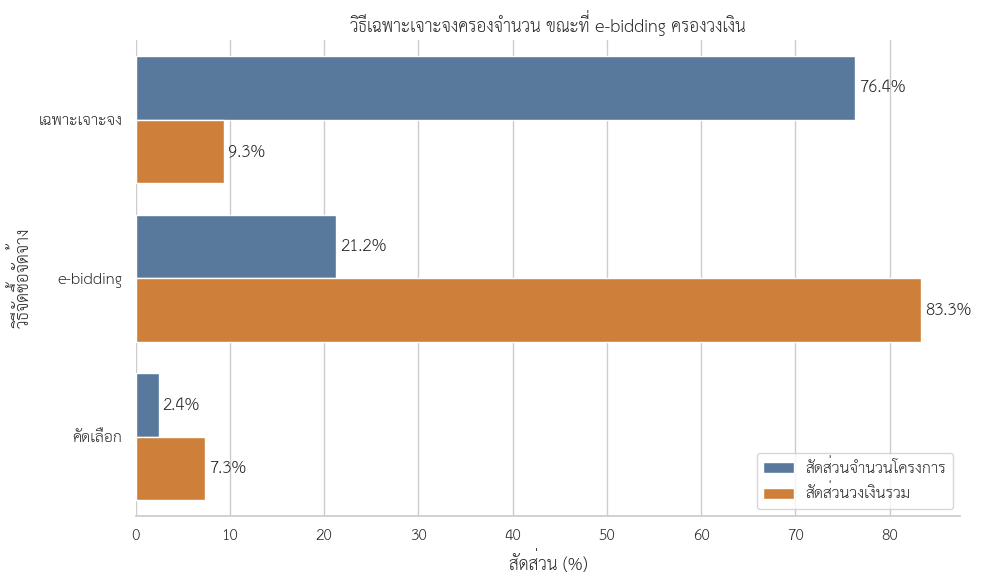

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_project_and_budget_share_by_method.png


In [17]:
method_label_map = {
    'เฉพาะเจาะจง': 'เฉพาะเจาะจง',
    'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-bidding',
    'คัดเลือก': 'คัดเลือก',
    'ตกลงราคา': 'ตกลงราคา'
}

method_plot = (
    method_analysis.loc[
        method_analysis['project_count'].gt(2)
    ].copy()
)

method_plot['procurement_method'] = (
    method_plot[method_column].map(method_label_map)
)

method_plot = (
    method_plot[
        ['procurement_method', 'project_pct', 'budget_share_pct']
    ]
    .melt(
        id_vars='procurement_method',
        var_name='measure',
        value_name='percentage'
    )
)

method_plot['measure'] = method_plot['measure'].map({
    'project_pct': 'สัดส่วนจำนวนโครงการ',
    'budget_share_pct': 'สัดส่วนวงเงินรวม'
})

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=method_plot,
    y='procurement_method',
    x='percentage',
    hue='measure',
    palette=['#4C78A8', '#E67E22'],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

ax.set_title('วิธีเฉพาะเจาะจงครองจำนวน ขณะที่ e-bidding ครองวงเงิน')
ax.set_xlabel('สัดส่วน (%)')
ax.set_ylabel('วิธีจัดซื้อจัดจ้าง')
ax.legend(title='')
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig03_02_project_and_budget_share_by_method.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Figure saved: {figure_path}')


In [18]:
budget_concentration = (
    project_data
    .assign(
        budget_le_500k=(
            project_data[
                budget_column
            ].le(500_000)
        ),
        budget_400k_to_500k=(
            project_data[
                budget_column
            ].gt(400_000)
            & project_data[
                budget_column
            ].le(500_000)
        ),
        budget_490k_to_500k=(
            project_data[
                budget_column
            ].ge(490_000)
            & project_data[
                budget_column
            ].le(500_000)
        ),
        budget_exactly_500k=(
            project_data[
                budget_column
            ].eq(500_000)
        )
    )
    .groupby(method_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        budget_le_500k_count=(
            'budget_le_500k',
            'sum'
        ),
        budget_400k_to_500k_count=(
            'budget_400k_to_500k',
            'sum'
        ),
        budget_490k_to_500k_count=(
            'budget_490k_to_500k',
            'sum'
        ),
        budget_exactly_500k_count=(
            'budget_exactly_500k',
            'sum'
        )
    )
    .reset_index()
)

count_columns = [
    'budget_le_500k_count',
    'budget_400k_to_500k_count',
    'budget_490k_to_500k_count',
    'budget_exactly_500k_count'
]

for column in count_columns:
    percentage_column = (
        column
        .replace('_count', '_pct')
    )

    budget_concentration[
        percentage_column
    ] = (
        budget_concentration[column]
        .div(
            budget_concentration[
                'project_count'
            ]
        )
        .mul(100)
    )

display(
    budget_concentration[
        [
            method_column,
            'project_count',
            'budget_le_500k_pct',
            'budget_400k_to_500k_pct',
            'budget_490k_to_500k_pct',
            'budget_exactly_500k_pct'
        ]
    ]
)

,ชื่อวิธีการจัดซื้อจัดจ้าง,project_count,budget_le_500k_pct,budget_400k_to_500k_pct,budget_490k_to_500k_pct,budget_exactly_500k_pct
0,คัดเลือก,4352,2.25,0.51,0.11,0.02
1,ตกลงราคา,2,100.00,0.00,0.00,0.00
2,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),37973,1.19,0.46,0.21,0.10
3,เฉพาะเจาะจง,136651,99.57,32.72,19.14,4.75


### กำหนดกลุ่มศึกษาหลัก

กลุ่มศึกษาหลักประกอบด้วยโครงการวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาท จำนวน 136,070 โครงการ หรือ 76.03% ของโครงการก่อสร้างทั้งหมด

การเลือกกลุ่มนี้อ้างอิงบริบทกฎหมายและผล EDA แต่ไม่ได้หมายความว่าโครงการในกลุ่มผิดปกติ


In [19]:
study_population_mask = (
    project_data[method_column].eq('เฉพาะเจาะจง')
    & project_data[budget_column].le(500_000)
)

study_project_data = (
    project_data.loc[study_population_mask]
    .copy()
)

study_population_summary = pd.Series({
    'โครงการก่อสร้างทั้งหมด': len(project_data),
    'กลุ่มศึกษาหลัก': len(study_project_data),
    'สัดส่วนของโครงการก่อสร้างทั้งหมด (%)': (
        len(study_project_data) / len(project_data) * 100
    )
}, name='value')

display(study_population_summary)


,value
โครงการก่อสร้างทั้งหมด,"178,978.00"
กลุ่มศึกษาหลัก,"136,070.00"
สัดส่วนของโครงการก่อสร้างทั้งหมด (%),76.03


### 3.3 วงเงินกระจุกบริเวณใต้เส้น 500,000 บาทหรือไม่

แสดงข้อมูลตั้งแต่ 400,000–550,000 บาทเพื่อเปรียบเทียบทั้งสองฝั่งของเส้นแบ่งตามกฎหมาย ก่อนเลือกช่วงใกล้เพดานไปวิเคราะห์รูปแบบเกิดซ้ำ


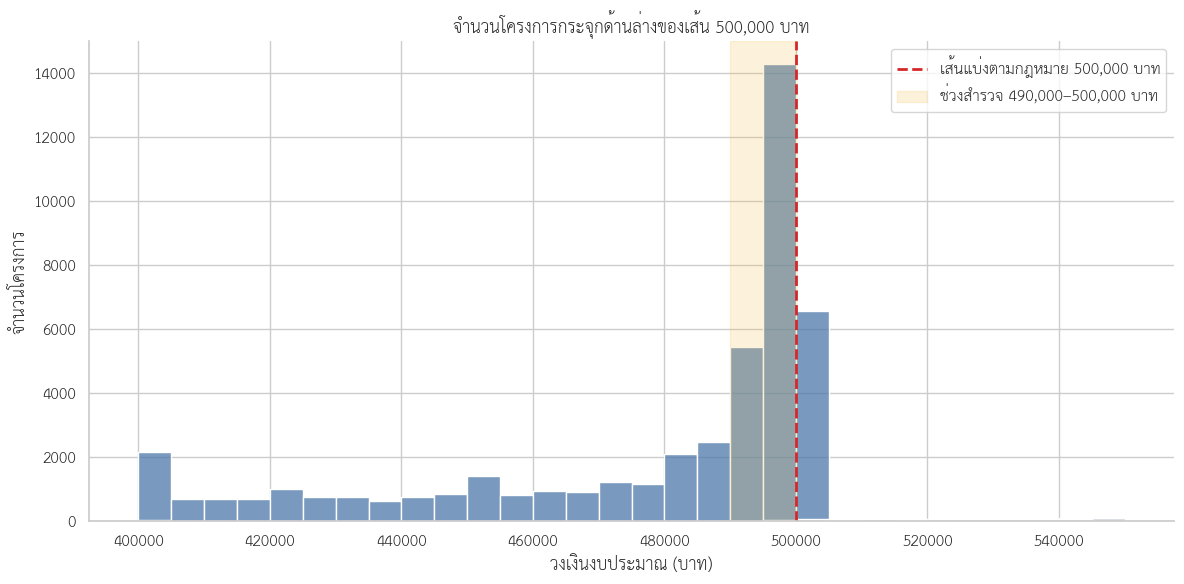

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_budget_distribution_around_500k.png


In [20]:
threshold_plot_data = (
    project_data.loc[
        project_data[budget_column].between(
            400_000,
            550_000,
            inclusive='both'
        ),
        [budget_column, method_column]
    ]
    .copy()
)

threshold_plot_data['method_group'] = np.where(
    threshold_plot_data[method_column].eq('เฉพาะเจาะจง'),
    'วิธีเฉพาะเจาะจง',
    'วิธีอื่น'
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=threshold_plot_data,
    x=budget_column,
    hue='method_group',
    binwidth=5_000,
    multiple='stack',
    palette={
        'วิธีเฉพาะเจาะจง': '#4C78A8',
        'วิธีอื่น': '#B8BDC6'
    },
    ax=ax
)

ax.axvline(
    500_000,
    color='#D62728',
    linestyle='--',
    linewidth=2,
    label='เส้นแบ่งตามกฎหมาย 500,000 บาท'
)

ax.axvspan(
    490_000,
    500_000,
    color='#F2C14E',
    alpha=0.20,
    label='ช่วงสำรวจ 490,000–500,000 บาท'
)

ax.set_title('จำนวนโครงการกระจุกด้านล่างของเส้น 500,000 บาท')
ax.set_xlabel('วงเงินงบประมาณ (บาท)')
ax.set_ylabel('จำนวนโครงการ')
ax.ticklabel_format(style='plain', axis='x')
ax.spines[['top', 'right']].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='')

plt.tight_layout()

figure_path = figure_directory / 'fig03_03_budget_distribution_around_500k.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Figure saved: {figure_path}')


### การตีความเส้นแบ่ง

พบโครงการในช่วง 490,000–500,000 บาท 26,154 โครงการ หรือ 19.22% ของกลุ่มศึกษา และมี 6,485 โครงการที่วงเงินเท่ากับ 500,000 บาท

500,000 บาทเป็นเกณฑ์ตามกฎหมาย ส่วนขอบล่าง 490,000 บาทเป็นช่วงสำรวจของทีม จึงต้องตรวจหลายหน้าต่างวงเงินและไม่ใช้การอยู่ใกล้เส้นแบ่งเป็นข้อสรุปเรื่องการแบ่งโครงการ


In [21]:
near_threshold_windows = [
    (450_000, 500_000, '450,000–500,000'),
    (480_000, 500_000, '480,000–500,000'),
    (490_000, 500_000, '490,000–500,000'),
    (495_000, 500_000, '495,000–500,000')
]

near_threshold_sensitivity = pd.DataFrame([
    {
        'ช่วงวงเงิน': label,
        'project_count': (
            study_project_data[budget_column]
            .between(lower, upper, inclusive='both')
            .sum()
        )
    }
    for lower, upper, label in near_threshold_windows
])

near_threshold_sensitivity['project_pct'] = (
    near_threshold_sensitivity['project_count']
    / len(study_project_data)
    * 100
)

exact_500k_count = (
    study_project_data[budget_column].eq(500_000).sum()
)

display(near_threshold_sensitivity)
print(f'โครงการที่มีวงเงินเท่ากับ 500,000 บาท: {exact_500k_count:,}')


,ช่วงวงเงิน,project_count,project_pct
0,"450,000–500,000",37198,27.34
1,"480,000–500,000",30697,22.56
2,"490,000–500,000",26154,19.22
3,"495,000–500,000",20734,15.24


โครงการที่มีวงเงินเท่ากับ 500,000 บาท: 6,485


### 3.4 ราคาที่ตกลงสัมพันธ์กับงบประมาณและราคากลางอย่างไร

ใช้กลุ่มศึกษาหลักเป็นฐาน เปรียบเทียบราคาที่ตกลงกับงบประมาณและราคากลางแยกกัน เพื่อหลีกเลี่ยงกราฟที่ต้องอ่านอัตราส่วนสามมิติพร้อมกัน

เกณฑ์ส่วนต่างในส่วนนี้เป็นเกณฑ์สำรวจของการศึกษา ไม่ใช่เกณฑ์ตามกฎหมาย และจะทดสอบความไวเพิ่มเติมใน Notebook 04


In [22]:
price_analysis_data = study_project_data.copy()

price_analysis_data['reference_to_budget_ratio'] = (
    price_analysis_data[reference_price_column]
    / price_analysis_data[budget_column]
)

price_analysis_data['usable_reference_price'] = (
    price_analysis_data[reference_price_column].notna()
    & price_analysis_data['reference_to_budget_ratio']
    .between(0.50, 1.50, inclusive='both')
)

budget_difference = (
    price_analysis_data[awarded_price_column]
    - price_analysis_data[budget_column]
)

reference_difference = (
    price_analysis_data[awarded_price_column]
    - price_analysis_data[reference_price_column]
)

price_analysis_data['budget_comparison'] = np.select(
    [
        budget_difference.lt(0),
        budget_difference.eq(0)
    ],
    ['ต่ำกว่า', 'เท่ากับ'],
    default='สูงกว่า'
)

price_analysis_data['reference_comparison'] = np.select(
    [
        reference_difference.lt(0),
        reference_difference.eq(0)
    ],
    ['ต่ำกว่า', 'เท่ากับ'],
    default='สูงกว่า'
)

comparison_order = ['ต่ำกว่า', 'เท่ากับ', 'สูงกว่า']

budget_comparison_summary = (
    price_analysis_data['budget_comparison']
    .value_counts()
    .reindex(comparison_order, fill_value=0)
)

reference_comparison_summary = (
    price_analysis_data.loc[
        price_analysis_data['usable_reference_price'],
        'reference_comparison'
    ]
    .value_counts()
    .reindex(comparison_order, fill_value=0)
)

price_comparison_summary = pd.DataFrame({
    'สถานะ': comparison_order,
    'เทียบวงเงินงบประมาณ': budget_comparison_summary.values,
    'เทียบราคากลางที่ใช้งานได้': reference_comparison_summary.values
})

display(price_comparison_summary)


,สถานะ,เทียบวงเงินงบประมาณ,เทียบราคากลางที่ใช้งานได้
0,ต่ำกว่า,79009,96558
1,เท่ากับ,56804,38211
2,สูงกว่า,257,573


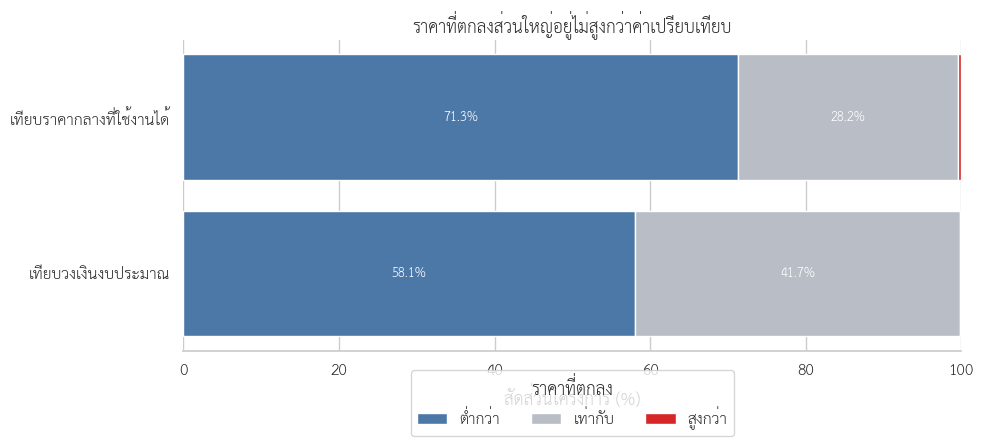

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_04_awarded_price_comparison.png


In [23]:
price_plot = (
    price_comparison_summary
    .set_index('สถานะ')
    .T
)

price_plot_pct = (
    price_plot
    .div(price_plot.sum(axis=1), axis=0)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 4.8))

left = np.zeros(len(price_plot_pct))

colors = {
    'ต่ำกว่า': '#4C78A8',
    'เท่ากับ': '#B8BDC6',
    'สูงกว่า': '#D62728'
}

for status in comparison_order:
    values = price_plot_pct[status].values
    bars = ax.barh(
        price_plot_pct.index,
        values,
        left=left,
        label=status,
        color=colors[status]
    )

    labels = [
        f'{value:.1f}%' if value >= 3 else ''
        for value in values
    ]
    ax.bar_label(
        bars,
        labels=labels,
        label_type='center',
        color='white',
        fontsize=9
    )
    left += values

ax.set_title('ราคาที่ตกลงส่วนใหญ่อยู่ไม่สูงกว่าค่าเปรียบเทียบ')
ax.set_xlabel('สัดส่วนโครงการ (%)')
ax.set_ylabel('')
ax.set_xlim(0, 100)
ax.legend(title='ราคาที่ตกลง', ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.30))
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig03_04_awarded_price_comparison.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Figure saved: {figure_path}')


### ข้อค้นพบจากการเปรียบเทียบราคา

ในกลุ่มศึกษาหลัก ราคาที่ตกลงต่ำกว่างบประมาณ 79,009 โครงการ เท่ากับงบประมาณ 56,804 โครงการ และสูงกว่า 257 โครงการ

สำหรับ 135,342 โครงการที่มีราคากลางใช้งานได้ ราคาที่ตกลงต่ำกว่าราคากลาง 96,558 โครงการ เท่ากับ 38,211 โครงการ และสูงกว่า 573 โครงการ

ส่วนใหญ่จึงไม่สูงกว่าค่าเปรียบเทียบ ขณะที่โครงการส่วนน้อยที่สูงกว่าจะส่งต่อไปทดสอบเกณฑ์จำนวนเงินและร้อยละใน Notebook 04


## 4. EDA เสริม

### 4.1 การวิเคราะห์ตามหน่วยงาน

ส่วนนี้เปรียบเทียบหน่วยงานในสองมิติ ได้แก่ จำนวนโครงการ
และวงเงินงบประมาณรวม เพื่อแยกหน่วยงานที่ดำเนินโครงการจำนวนมาก
ออกจากหน่วยงานที่รับผิดชอบโครงการมูลค่าสูง

การวิเคราะห์ใช้ `ชื่อหน่วยงาน` จากข้อมูลระดับโครงการ
และยังไม่รวม `ชื่อหน่วยงานย่อย`

In [24]:
agency_column = 'ชื่อหน่วยงาน'

agency_summary = (
    project_data
    .groupby(agency_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_budget=(
            budget_column,
            'sum'
        ),
        median_budget=(
            budget_column,
            'median'
        ),
        total_awarded_price=(
            awarded_price_column,
            'sum'
        ),
        median_budget_saving_pct=(
            'budget_saving_pct',
            'median'
        ),
        median_reference_discount_pct=(
            'reference_discount_pct',
            'median'
        )
    )
    .reset_index()
)

agency_summary['project_share_pct'] = (
    agency_summary['project_count']
    .div(
        agency_summary[
            'project_count'
        ].sum()
    )
    .mul(100)
)

agency_summary['budget_share_pct'] = (
    agency_summary['total_budget']
    .div(
        agency_summary[
            'total_budget'
        ].sum()
    )
    .mul(100)
)

agency_summary['total_budget_billion'] = (
    agency_summary['total_budget']
    .div(1_000_000_000)
)

In [25]:
top_agencies_by_count = (
    agency_summary
    .nlargest(
        10,
        'project_count'
    )
    [
        [
            agency_column,
            'project_count',
            'project_share_pct',
            'total_budget_billion',
            'median_budget'
        ]
    ]
)

display(top_agencies_by_count)

,ชื่อหน่วยงาน,project_count,project_share_pct,total_budget_billion,median_budget
21,กรมทางหลวง,5774,3.23,95.33,"8,200,000.00"
22,กรมทางหลวงชนบท,5484,3.06,44.91,"2,800,000.00"
5,กรมการปกครอง,4461,2.49,3.35,"373,000.00"
35,กรมพัฒนาที่ดิน,3531,1.97,2.49,"189,600.00"
84,การไฟฟ้าส่วนภูมิภาค,3185,1.78,5.83,"219,613.22"
15,กรมชลประทาน,2414,1.35,38.03,"833,200.00"
76,การประปาส่วนภูมิภาค,2022,1.13,17.55,"395,968.00"
65,กรุงเทพมหานคร,997,0.56,13.07,"2,004,000.00"
75,การประปานครหลวง,934,0.52,4.38,"498,593.50"
64,กรมโยธาธิการและผังเมือง,780,0.44,32.31,"20,000,000.00"


In [26]:
top_agencies_by_budget = (
    agency_summary
    .nlargest(
        10,
        'total_budget'
    )
    [
        [
            agency_column,
            'total_budget_billion',
            'budget_share_pct',
            'project_count',
            'median_budget',
            'median_budget_saving_pct',
            'median_reference_discount_pct'
        ]
    ]
)

display(top_agencies_by_budget)

,ชื่อหน่วยงาน,total_budget_billion,budget_share_pct,project_count,median_budget,median_budget_saving_pct,median_reference_discount_pct
21,กรมทางหลวง,95.33,20.03,5774,"8,200,000.00",0.55,0.11
22,กรมทางหลวงชนบท,44.91,9.44,5484,"2,800,000.00",0.08,0.20
15,กรมชลประทาน,38.03,7.99,2414,"833,200.00",0.47,0.88
64,กรมโยธาธิการและผังเมือง,32.31,6.79,780,"20,000,000.00",1.00,0.91
76,การประปาส่วนภูมิภาค,17.55,3.69,2022,"395,968.00",0.97,0.21
65,กรุงเทพมหานคร,13.07,2.75,997,"2,004,000.00",7.24,5.82
82,การไฟฟ้านครหลวง,9.40,1.98,86,"1,622,500.00",13.82,0.76
656,สำนักงานตำรวจแห่งชาติ,6.70,1.41,449,"8,394,600.00",2.06,3.36
19,กรมทรัพยากรน้ำ,6.28,1.32,286,"13,250,000.00",0.59,0.23
20,กรมทรัพยากรน้ำบาดาล,6.15,1.29,77,"5,147,800.00",0.21,0.15


### ข้อค้นพบตามหน่วยงาน

กรมทางหลวงมีจำนวนโครงการมากที่สุด 5,774 โครงการ และมีวงเงินรวม
สูงที่สุดประมาณ 95.33 พันล้านบาท หรือ 20.03% ของวงเงินทั้งหมด
จึงเป็นหน่วยงานที่มีบทบาทสูงทั้งด้านจำนวนและมูลค่าโครงการ

กรมทางหลวงชนบทและกรมชลประทานอยู่ในอันดับสูงทั้งสองมิติเช่นกัน
ขณะที่กรมโยธาธิการและผังเมืองมีเพียง 780 โครงการ แต่มีวงเงินรวม
สูงถึง 32.31 พันล้านบาท และมีวงเงินมัธยฐาน 20 ล้านบาท
สะท้อนว่าเป็นหน่วยงานที่มีโครงการขนาดใหญ่โดยทั่วไป

ในทางตรงกันข้าม กรมการปกครองและกรมพัฒนาที่ดินมีจำนวนโครงการ
มากเป็นอันดับต้น แต่มีวงเงินมัธยฐานเพียง 373,000 และ 189,600 บาท
ตามลำดับ แสดงให้เห็นว่าการจัดอันดับจากจำนวนโครงการและวงเงินรวม
ให้ภาพที่แตกต่างกัน

หน่วยงาน 4 อันดับแรกตามวงเงินรวมครองวงเงินประมาณ 44.25%
ของข้อมูลทั้งหมด โดยส่วนใหญ่เป็นหน่วยงานที่รับผิดชอบ
โครงสร้างพื้นฐานด้านถนน น้ำ และงานโยธา

In [ ]:
agency_budget_plot = (
    agency_summary
    .nlargest(10, 'total_budget')
    .sort_values(
        'total_budget_billion',
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    agency_budget_plot[agency_column],
    agency_budget_plot['total_budget_billion'],
    color='#4C78A8'
)

ax.bar_label(
    bars,
    labels=[
        f'{budget:.1f} พันล้าน'
        for budget in agency_budget_plot[
            'total_budget_billion'
        ]
    ],
    padding=3
)

ax.set_title('10 หน่วยงานที่มีวงเงินโครงการก่อสร้างรวมสูงสุด')
ax.set_xlabel('วงเงินรวม (พันล้านบาท)')
ax.set_ylabel('หน่วยงาน')
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig03_05_top_agencies_by_construction_budget.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'บันทึกรูป: {figure_path}')


### 4.2 การกระจายตามพื้นที่

ส่วนนี้เปรียบเทียบจำนวนโครงการและวงเงินรวมในแต่ละจังหวัด
เพื่อดูว่าพื้นที่ที่มีโครงการจำนวนมากเป็นพื้นที่เดียวกับ
พื้นที่ที่ได้รับวงเงินรวมสูงหรือไม่

ข้อมูลจังหวัดระบุสถานที่ของโครงการตามชุดข้อมูลต้นทาง
จึงไม่ได้หมายถึงที่ตั้งสำนักงานใหญ่ของหน่วยงานหรือผู้รับจ้าง

In [28]:
province_column = 'จังหวัด'

province_summary = (
    project_data
    .groupby(province_column)
    .agg(
        project_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_budget=(
            budget_column,
            'sum'
        ),
        median_budget=(
            budget_column,
            'median'
        ),
        total_awarded_price=(
            awarded_price_column,
            'sum'
        ),
        median_budget_saving_pct=(
            'budget_saving_pct',
            'median'
        ),
        median_reference_discount_pct=(
            'reference_discount_pct',
            'median'
        )
    )
    .reset_index()
)

province_summary['project_share_pct'] = (
    province_summary['project_count']
    .div(
        province_summary[
            'project_count'
        ].sum()
    )
    .mul(100)
)

province_summary['budget_share_pct'] = (
    province_summary['total_budget']
    .div(
        province_summary[
            'total_budget'
        ].sum()
    )
    .mul(100)
)

province_summary['total_budget_billion'] = (
    province_summary['total_budget']
    .div(1_000_000_000)
)

In [29]:
display(
    province_summary
    .nlargest(
        10,
        'project_count'
    )
    [
        [
            province_column,
            'project_count',
            'project_share_pct',
            'total_budget_billion',
            'median_budget'
        ]
    ]
)

,จังหวัด,project_count,project_share_pct,total_budget_billion,median_budget
18,นครราชสีมา,8641,4.83,15.30,"362,000.00"
68,อุบลราชธานี,7181,4.01,8.56,"321,800.00"
5,ขอนแก่น,6605,3.69,10.60,"400,000.00"
71,เชียงใหม่,5894,3.29,11.35,"350,000.00"
65,อุดรธานี,5619,3.14,7.26,"330,000.00"
48,ศรีสะเกษ,5328,2.98,5.67,"308,750.00"
1,กรุงเทพมหานคร,4825,2.70,177.54,"4,460,000.00"
25,บุรีรัมย์,4675,2.61,5.37,"330,000.00"
60,สุรินทร์,4285,2.39,4.45,"358,000.00"
70,เชียงราย,4121,2.30,5.02,"341,400.00"


In [30]:
display(
    province_summary
    .nlargest(
        10,
        'total_budget'
    )
    [
        [
            province_column,
            'total_budget_billion',
            'budget_share_pct',
            'project_count',
            'median_budget',
            'median_budget_saving_pct',
            'median_reference_discount_pct'
        ]
    ]
)

,จังหวัด,total_budget_billion,budget_share_pct,project_count,median_budget,median_budget_saving_pct,median_reference_discount_pct
1,กรุงเทพมหานคร,177.54,37.30,4825,"4,460,000.00",1.24,0.80
18,นครราชสีมา,15.30,3.22,8641,"362,000.00",0.60,0.57
8,ชลบุรี,11.82,2.48,2854,"495,000.00",1.31,0.45
71,เชียงใหม่,11.35,2.38,5894,"350,000.00",0.50,0.56
5,ขอนแก่น,10.60,2.23,6605,"400,000.00",0.35,0.38
50,สงขลา,10.15,2.13,2641,"499,000.00",0.30,0.29
68,อุบลราชธานี,8.56,1.80,7181,"321,800.00",0.34,0.31
21,นนทบุรี,8.09,1.70,709,"671,498.83",4.36,3.00
19,นครศรีธรรมราช,7.42,1.56,3782,"448,000.00",0.34,0.51
65,อุดรธานี,7.26,1.53,5619,"330,000.00",0.20,0.23


### ข้อค้นพบตามพื้นที่

นครราชสีมามีจำนวนโครงการมากที่สุด 8,641 โครงการ
รองลงมาคืออุบลราชธานี 7,181 โครงการ และขอนแก่น
6,605 โครงการ โดยจังหวัดที่มีโครงการจำนวนมากส่วนใหญ่
มีวงเงินมัธยฐานประมาณ 300,000–400,000 บาท

กรุงเทพมหานครมีจำนวน 4,825 โครงการ หรือ 2.70%
ของโครงการทั้งหมด แต่มีวงเงินรวมสูงถึง 177.54 พันล้านบาท
คิดเป็น 37.30% ของวงเงินทั้งหมด และมีวงเงินมัธยฐาน
4.46 ล้านบาท

ผลนี้แสดงว่าจังหวัดที่มีจำนวนโครงการมากที่สุดไม่จำเป็นต้องเป็น
จังหวัดที่มีวงเงินรวมสูงที่สุด โดยกรุงเทพมหานครมีโครงการ
ขนาดใหญ่กว่าจังหวัดอื่นโดยทั่วไป

การวิเคราะห์พื้นที่จะใช้เป็นบริบทประกอบการอธิบายข้อมูล
แต่จะไม่เป็นแกนหลักของตัวชี้วัดเพื่อการตรวจสอบ

### 4.3 การทำความเข้าใจข้อมูลผู้รับจ้าง

การวิเคราะห์ผู้รับจ้างใช้ข้อมูลทุกแถว เพราะหนึ่งโครงการอาจมีหลายสัญญา
หลายผู้ชนะ หรือเป็นกลุ่มผู้รับจ้างแบบ Joint Venture (JV)

ก่อนรวมมูลค่าตามผู้รับจ้าง ต้องตรวจความสัมพันธ์ระหว่างเลขประจำตัว
นิติบุคคลกับชื่อผู้ชนะ และแยกแถวสมาชิก JV เพื่อป้องกันการนับมูลค่าซ้ำ


In [31]:
supplier_id_column = (
    'เลขประจำตัวนิติบุคคล 13 หลัก'
)

supplier_name_column = (
    'ชื่อผู้ชนะการเสนอราคา'
)

print('Most frequent supplier IDs:')

display(
    construction_data[
        supplier_id_column
    ]
    .value_counts(
        dropna=False
    )
    .head(15)
)

print('\nMost frequent supplier names:')

display(
    construction_data[
        supplier_name_column
    ]
    .value_counts(
        dropna=False
    )
    .head(15)
)

Most frequent supplier IDs:


,count
เลขประจำตัวนิติบุคคล 13 หลัก,
0523546000132,575
0405530000254,314
0365557000060,294
0523543000263,278
0483540000441,258
0333541000381,244
0363553000331,238
0523551000579,214
0463536000181,204



Most frequent supplier names:


,count
ชื่อผู้ชนะการเสนอราคา,
ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม,575
บริษัท ชัยศิริคอนกรีต จำกัด,310
บริษัท ภูเขียวนครคอนกรีต จำกัด,294
ห้างหุ้นส่วนจำกัด สินทวีเคหะกิจ,278
ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,258
ห้างหุ้นส่วนจำกัด อึ้งเกี่ยอู๋,244
ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,238
ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,212
ห้างหุ้นส่วนจำกัด ทรงวัฒนะคอนกรีต,204


In [32]:
supplier_id_profile = (
    construction_data
    .groupby(supplier_id_column)
    [supplier_name_column]
    .nunique()
)

supplier_name_profile = (
    construction_data
    .groupby(supplier_name_column)
    [supplier_id_column]
    .nunique()
)

supplier_relationship_summary = pd.Series({
    'Unique supplier IDs': (
        construction_data[
            supplier_id_column
        ].nunique()
    ),
    'Unique supplier names': (
        construction_data[
            supplier_name_column
        ].nunique()
    ),
    'Supplier IDs linked to multiple names': (
        supplier_id_profile.gt(1).sum()
    ),
    'Supplier names linked to multiple IDs': (
        supplier_name_profile.gt(1).sum()
    )
})

display(
    supplier_relationship_summary
    .to_frame(name='value')
)

,value
Unique supplier IDs,33685
Unique supplier names,38826
Supplier IDs linked to multiple names,4234
Supplier names linked to multiple IDs,253


### ข้อค้นพบเกี่ยวกับรหัสผู้รับจ้าง

ข้อมูลมีเลขประจำตัวนิติบุคคลที่ไม่ซ้ำ 33,685 ค่า
และชื่อผู้ชนะการเสนอราคาที่ไม่ซ้ำ 38,826 ค่า

พบเลขนิติบุคคล 4,234 รหัสที่เชื่อมโยงกับชื่อผู้ชนะมากกว่าหนึ่งรูปแบบ
ซึ่งอาจเกิดจากความแตกต่างของการสะกด คำนำหน้า สาขา
หรือรูปแบบการบันทึกชื่อ ขณะเดียวกันพบชื่อผู้ชนะ 253 ชื่อ
ที่เชื่อมโยงกับเลขนิติบุคคลมากกว่าหนึ่งรหัส

ดังนั้น การวิเคราะห์จะใช้เลขประจำตัวนิติบุคคลเป็นรหัสหลัก
และใช้ชื่อที่พบบ่อยที่สุดของแต่ละรหัสเป็นชื่อสำหรับแสดงผล
โดยไม่รวมผู้รับจ้างจากชื่อเพียงอย่างเดียว

In [33]:
contract_budget_column = 'วงเงินงบประมาณในสัญญา (บาท)'

project_awarded_total = (
    project_data[
        awarded_price_column
    ].sum()
)

raw_contract_budget_total = (
    construction_data[
        contract_budget_column
    ].sum()
)

raw_value_difference = (
    raw_contract_budget_total
    - project_awarded_total
)

raw_value_reconciliation = pd.Series({
    'Project awarded total': (
        project_awarded_total
    ),
    'Raw contract budget total': (
        raw_contract_budget_total
    ),
    'Raw difference': (
        raw_value_difference
    ),
    'Raw difference pct': (
        raw_value_difference
        / project_awarded_total
        * 100
    ),
    'Missing contract budget rows': (
        construction_data[
            contract_budget_column
        ]
        .isna()
        .sum()
    )
})

display(
    raw_value_reconciliation
    .to_frame(name='value')
)

,value
Project awarded total,"450,676,863,445.93"
Raw contract budget total,"463,911,809,538.91"
Raw difference,"13,234,946,092.98"
Raw difference pct,2.94
Missing contract budget rows,90.00


In [34]:
raw_contract_value_by_project = (
    construction_data
    .groupby('รหัสโครงการ')[
        contract_budget_column
    ]
    .sum(min_count=1)
    .rename('raw_contract_budget_sum')
    .reset_index()
)

raw_project_value_check = (
    project_data[
        [
            'รหัสโครงการ',
            awarded_price_column
        ]
    ]
    .merge(
        raw_contract_value_by_project,
        on='รหัสโครงการ',
        how='left'
    )
)

raw_project_value_check['difference'] = (
    raw_project_value_check[
        'raw_contract_budget_sum'
    ]
    - raw_project_value_check[
        awarded_price_column
    ]
)

raw_project_value_check['is_matched'] = np.isclose(
    raw_project_value_check[
        'raw_contract_budget_sum'
    ],
    raw_project_value_check[
        awarded_price_column
    ],
    rtol=0,
    atol=1,
    equal_nan=False
)

raw_reconciliation_summary = pd.Series({
    'Projects checked': (
        len(raw_project_value_check)
    ),
    'Matched projects': (
        raw_project_value_check[
            'is_matched'
        ].sum()
    ),
    'Unmatched projects': (
        ~raw_project_value_check[
            'is_matched'
        ]
    ).sum(),
    'Matched pct': (
        raw_project_value_check[
            'is_matched'
        ].mean()
        * 100
    )
})

display(
    raw_reconciliation_summary
    .to_frame(name='value')
)

,value
Projects checked,"178,978.00"
Matched projects,"178,616.00"
Unmatched projects,362.00
Matched pct,99.80


### การตรวจพบโครงสร้าง Joint Venture (JV)

เมื่อรวมวงเงินทุกแถวโดยตรง ยอดระดับสัญญาตรงกับราคาที่ตกลง
178,616 จาก 178,978 โครงการ และพบส่วนต่าง 362 โครงการ
ยอดรวมดิบสูงกว่าระดับโครงการประมาณ 13.23 พันล้านบาท

บางโครงการมีทั้งแถวของกลุ่ม JV ซึ่งบันทึกมูลค่าสัญญาทั้งก้อน
และแถวบริษัทสมาชิกซึ่งบันทึกส่วนแบ่งของแต่ละราย หากรวมทุกแถว
พร้อมกันจะเกิดการนับมูลค่าซ้ำ

การวิเคราะห์ผู้รับจ้างจึงเก็บแถวของกลุ่ม JV และไม่นับแถวสมาชิกซ้ำ
ก่อนตรวจสอบยอดอีกครั้ง


In [35]:
construction_data[
    'is_joint_venture_member'
] = (
    construction_data[
        supplier_name_column
    ]
    .astype('string')
    .str.contains(
        'สัญญากิจการค้าร่วม',
        na=False
    )
)

joint_venture_member_summary = pd.Series({
    'Joint-venture member rows': (
        construction_data[
            'is_joint_venture_member'
        ].sum()
    ),
    'Projects with member rows': (
        construction_data.loc[
            construction_data[
                'is_joint_venture_member'
            ],
            'รหัสโครงการ'
        ].nunique()
    ),
    'Member-row contract value': (
        construction_data.loc[
            construction_data[
                'is_joint_venture_member'
            ],
            contract_budget_column
        ].sum()
    )
})

display(
    joint_venture_member_summary
    .to_frame(name='value')
)

,value
Joint-venture member rows,710.00
Projects with member rows,362.00
Member-row contract value,"13,056,748,297.50"


In [36]:
supplier_entity_data = (
    construction_data
    .loc[
        ~construction_data[
            'is_joint_venture_member'
        ]
    ]
    .copy()
)

entity_value_by_project = (
    supplier_entity_data
    .groupby('รหัสโครงการ')[
        contract_budget_column
    ]
    .sum(min_count=1)
    .rename('entity_contract_value_sum')
    .reset_index()
)

entity_reconciliation = (
    project_data[
        [
            'รหัสโครงการ',
            awarded_price_column
        ]
    ]
    .merge(
        entity_value_by_project,
        on='รหัสโครงการ',
        how='left'
    )
)

entity_reconciliation['difference'] = (
    entity_reconciliation[
        'entity_contract_value_sum'
    ]
    - entity_reconciliation[
        awarded_price_column
    ]
)

entity_reconciliation['is_matched'] = np.isclose(
    entity_reconciliation[
        'entity_contract_value_sum'
    ],
    entity_reconciliation[
        awarded_price_column
    ],
    rtol=0,
    atol=1,
    equal_nan=False
)

entity_reconciliation_summary = pd.Series({
    'Supplier entity rows': (
        len(supplier_entity_data)
    ),
    'Projects checked': (
        len(entity_reconciliation)
    ),
    'Matched projects': (
        entity_reconciliation[
            'is_matched'
        ].sum()
    ),
    'Unmatched projects': (
        ~entity_reconciliation[
            'is_matched'
        ]
    ).sum(),
    'Matched pct': (
        entity_reconciliation[
            'is_matched'
        ].mean()
        * 100
    ),
    'Total absolute difference': (
        entity_reconciliation[
            'difference'
        ].abs().sum()
    )
})

display(
    entity_reconciliation_summary
    .to_frame(name='value')
)

,value
Supplier entity rows,"179,369.00"
Projects checked,"178,978.00"
Matched projects,"178,967.00"
Unmatched projects,11.00
Matched pct,99.99
Total absolute difference,"178,197,795.48"


In [37]:
matched_entity_project_ids = set(
    entity_reconciliation.loc[
        entity_reconciliation[
            'is_matched'
        ],
        'รหัสโครงการ'
    ]
)

supplier_analysis_data = (
    supplier_entity_data
    .loc[
        supplier_entity_data[
            'รหัสโครงการ'
        ].isin(
            matched_entity_project_ids
        )
        & supplier_entity_data[
            contract_budget_column
        ].notna()
    ]
    .copy()
)

print(
    f'Supplier entity rows used: '
    f'{len(supplier_analysis_data):,}'
)

print(
    f'Reconciled projects used: '
    f'{supplier_analysis_data["รหัสโครงการ"].nunique():,}'
)

Supplier entity rows used: 179,358
Reconciled projects used: 178,967


In [38]:
supplier_name_lookup = (
    supplier_analysis_data
    .groupby(
        [
            supplier_id_column,
            supplier_name_column
        ]
    )
    .size()
    .rename('name_count')
    .reset_index()
    .sort_values(
        [
            supplier_id_column,
            'name_count',
            supplier_name_column
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .drop_duplicates(
        subset=supplier_id_column,
        keep='first'
    )[
        [
            supplier_id_column,
            supplier_name_column
        ]
    ]
    .rename(
        columns={
            supplier_name_column:
            'supplier_display_name'
        }
    )
)

supplier_summary = (
    supplier_analysis_data
    .groupby(supplier_id_column)
    .agg(
        supplier_project_count=(
            'รหัสโครงการ',
            'nunique'
        ),
        supplier_record_count=(
            'รหัสโครงการ',
            'size'
        ),
        total_contract_value=(
            contract_budget_column,
            'sum'
        ),
        median_contract_value=(
            contract_budget_column,
            'median'
        )
    )
    .reset_index()
    .merge(
        supplier_name_lookup,
        on=supplier_id_column,
        how='left'
    )
)

supplier_summary[
    'total_contract_value_million'
] = (
    supplier_summary[
        'total_contract_value'
    ]
    .div(1_000_000)
)

supplier_summary[
    'value_share_pct'
] = (
    supplier_summary[
        'total_contract_value'
    ]
    .div(
        supplier_summary[
            'total_contract_value'
        ].sum()
    )
    .mul(100)
)

In [39]:
top_suppliers_by_projects = (
    supplier_summary
    .nlargest(
        15,
        'supplier_project_count'
    )[
        [
            supplier_id_column,
            'supplier_display_name',
            'supplier_project_count',
            'supplier_record_count',
            'total_contract_value_million'
        ]
    ]
)

top_suppliers_by_value = (
    supplier_summary
    .nlargest(
        15,
        'total_contract_value'
    )[
        [
            supplier_id_column,
            'supplier_display_name',
            'total_contract_value_million',
            'value_share_pct',
            'supplier_project_count',
            'median_contract_value'
        ]
    ]
)

display(top_suppliers_by_projects)
display(top_suppliers_by_value)

,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_display_name,supplier_project_count,supplier_record_count,total_contract_value_million
11084,0523546000132,ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม,575,575,284.68
8030,0405530000254,บริษัท ชัยศิริคอนกรีต จำกัด,310,310,250.54
7250,0365557000060,บริษัท ภูเขียวนครคอนกรีต จำกัด,294,294,107.70
11072,0523543000263,ห้างหุ้นส่วนจำกัด สินทวีเคหะกิจ,278,278,243.30
9875,0483540000441,ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,258,258,195.98
5997,0333541000381,ห้างหุ้นส่วนจำกัด อึ้งเกี่ยอู๋,244,244,78.66
7057,0363553000331,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,238,238,253.22
11107,0523551000579,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,212,212,916.32
9358,0463536000181,ห้างหุ้นส่วนจำกัด ทรงวัฒนะคอนกรีต,204,204,119.15
9189,0453555000272,ห้างหุ้นส่วนจำกัด อาร์พีซี แอสฟัลท์,193,193,292.99


,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_display_name,total_contract_value_million,value_share_pct,supplier_project_count,median_contract_value
249,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,"6,817.30",1.51,3,"1,885,400,000.00"
1570,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),"4,153.83",0.92,3,"84,900,000.00"
17912,0993000532988,กิจการร่วมค้า จีบีที,"3,870.55",0.86,1,"3,870,550,927.00"
1577,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),"3,285.00",0.73,1,"3,285,000,000.00"
17946,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,"3,282.80",0.73,1,"3,282,800,000.00"
1589,0107563000142,บริษัท ไร้ท์ทันเน็ลลิ่ง จำกัด (มหาชน),"2,969.90",0.66,13,"10,190,000.00"
237,0105509002602,บริษัท ซีวิล คอนสตรัคชั่น เซอร์วิสเซส แอนด์ โปรดักส์ จำกัด,"2,467.20",0.55,3,"14,986,000.00"
5552,0315561000656,บริษัท บุรีรัมย์พนาสิทธิ์ จำกัด,"2,418.68",0.54,53,"4,490,500.00"
355,0105534060360,บริษัท กรีนไลท์ อินเตอร์เนชั่นแนล จำกัด,"2,131.67",0.47,7,"34,485,000.00"
1590,0107563000169,บริษัท ซีวิลเอนจีเนียริง จำกัด (มหาชน),"2,049.47",0.45,8,"111,693,500.00"


### ข้อค้นพบเกี่ยวกับผู้รับจ้าง

พบแถวสมาชิก JV 710 แถว ครอบคลุม 362 โครงการ และมีมูลค่ารวม
ประมาณ 13.06 พันล้านบาท หลังไม่นับแถวสมาชิกซ้ำ ยอดตรงกัน
178,967 จาก 178,978 โครงการ หรือ 99.994% เหลือ 11 โครงการ
ที่ยอดยังไม่ตรงกัน

ผู้รับจ้างที่ได้โครงการจำนวนมากที่สุดไม่ใช่รายที่ได้มูลค่ารวมสูงที่สุด
จึงต้องพิจารณาทั้งจำนวนโครงการและมูลค่าสัญญาควบคู่กัน


In [40]:
supplier_pareto = (
    supplier_summary
    .sort_values(
        'total_contract_value',
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

supplier_pareto['supplier_rank'] = (
    supplier_pareto.index + 1
)

supplier_pareto['cumulative_value_pct'] = (
    supplier_pareto[
        'total_contract_value'
    ]
    .cumsum()
    .div(
        supplier_pareto[
            'total_contract_value'
        ].sum()
    )
    .mul(100)
)

total_suppliers = len(
    supplier_pareto
)

supplier_count_50 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(50)
    .idxmax()
    + 1
)

supplier_count_80 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(80)
    .idxmax()
    + 1
)

supplier_count_90 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(90)
    .idxmax()
    + 1
)

In [41]:
supplier_concentration_summary = pd.Series({
    'Supplier entities': (
        total_suppliers
    ),
    'Top 1 value share (%)': (
        supplier_pareto
        .head(1)[
            'value_share_pct'
        ].sum()
    ),
    'Top 10 value share (%)': (
        supplier_pareto
        .head(10)[
            'value_share_pct'
        ].sum()
    ),
    'Top 100 value share (%)': (
        supplier_pareto
        .head(100)[
            'value_share_pct'
        ].sum()
    ),
    'Suppliers accounting for 50%': (
        supplier_count_50
    ),
    'Supplier pct accounting for 50%': (
        supplier_count_50
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 80%': (
        supplier_count_80
    ),
    'Supplier pct accounting for 80%': (
        supplier_count_80
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 90%': (
        supplier_count_90
    ),
    'Supplier pct accounting for 90%': (
        supplier_count_90
        / total_suppliers
        * 100
    )
})

display(
    supplier_concentration_summary
    .to_frame(name='value')
)

,value
Supplier entities,"33,570.00"
Top 1 value share (%),1.51
Top 10 value share (%),7.42
Top 100 value share (%),27.83
Suppliers accounting for 50%,405.00
Supplier pct accounting for 50%,1.21
Suppliers accounting for 80%,"1,870.00"
Supplier pct accounting for 80%,5.57
Suppliers accounting for 90%,"3,902.00"
Supplier pct accounting for 90%,11.62


### ข้อค้นพบเกี่ยวกับการกระจายมูลค่าตามผู้รับจ้าง

หลังไม่นับแถวสมาชิก JV ซ้ำ พบผู้รับจ้างหรือกลุ่มผู้รับจ้าง 33,570 ราย รายใหญ่ที่สุดครองมูลค่า 1.51% และ 100 อันดับแรกครอง 27.83%

ผู้รับจ้าง 1,870 ราย หรือ 5.57% ครองมูลค่าสะสม 80% แต่ไม่มีรายเดียวครองภาพรวมประเทศสูงมาก ผลระดับประเทศจึงใช้เป็นบริบท ก่อนเปลี่ยนไปวิเคราะห์ความสัมพันธ์ภายในหน่วยงานย่อยใน Notebook 04


In [42]:
supplier_pareto[
    'cumulative_supplier_pct'
] = (
    supplier_pareto[
        'supplier_rank'
    ]
    .div(total_suppliers)
    .mul(100)
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    supplier_pareto['cumulative_supplier_pct'],
    supplier_pareto['cumulative_value_pct'],
    color='#4C78A8',
    linewidth=2
)

supplier_pct_80 = (
    supplier_count_80
    / total_suppliers
    * 100
)

ax.axhline(
    y=80,
    color='#D62728',
    linestyle='--',
    linewidth=1.5,
    label='มูลค่าสัญญาสะสม 80%'
)

ax.axvline(
    x=supplier_pct_80,
    color='#E67E22',
    linestyle='--',
    linewidth=1.5,
    label=(
        f'ผู้รับจ้าง {supplier_count_80:,} ราย '
        f'({supplier_pct_80:.1f}%)'
    )
)

ax.scatter(
    supplier_pct_80,
    80,
    color='#D62728',
    s=60,
    zorder=3
)

ax.set_title('มูลค่าสัญญาสะสมกระจุกอยู่ในผู้รับจ้างส่วนน้อย')
ax.set_xlabel('สัดส่วนผู้รับจ้างสะสม (%)')
ax.set_ylabel('สัดส่วนมูลค่าสัญญาสะสม (%)')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig03_06_cumulative_contract_value_by_supplier.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'บันทึกรูป: {figure_path}')


## 5. สรุป EDA

- โครงการไม่เกิน 500,000 บาทครอง 76.34% ของจำนวน แต่เพียง 8.23% ของวงเงินรวม
- วิธีเฉพาะเจาะจงครองจำนวน ขณะที่ e-bidding ครองวงเงิน
- กลุ่มศึกษาหลักมี 136,070 โครงการ
- ช่วง 490,000–500,000 บาทมี 26,154 โครงการ แต่เป็นช่วงวิเคราะห์ของทีม ไม่ใช่เกณฑ์ตามกฎหมาย
- ราคาที่ตกลงส่วนใหญ่ไม่สูงกว่างบประมาณหรือราคากลาง
- Notebook 04 จะทดสอบความไวของ threshold และตรวจการซ้อนทับของรูปแบบเกิดซ้ำ การพึ่งพาผู้รับจ้าง และส่วนต่างราคา


In [44]:
project_output_path = (
    data_path.parent
    / 'construction_projects_2569.csv'
)

project_data.to_csv(
    project_output_path,
    index=False,
    encoding='utf-8-sig'
)

print(
    f'Project-level data saved to:\n'
    f'{project_output_path}'
)

Project-level data saved to:
/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_projects_2569.csv


In [45]:
supplier_output_path = (
    data_path.parent
    / 'construction_supplier_summary_2569.csv'
)

supplier_summary.to_csv(
    supplier_output_path,
    index=False,
    encoding='utf-8-sig'
)

print(
    f'Supplier summary saved to:\n'
    f'{supplier_output_path}'
)

Supplier summary saved to:
/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_supplier_summary_2569.csv


In [46]:
output_files = [
    project_output_path,
    supplier_output_path
]

for file_path in output_files:
    print(
        f'{file_path.name}: '
        f'{file_path.stat().st_size / (1024 ** 2):,.2f} MB'
    )

construction_projects_2569.csv: 242.48 MB
construction_supplier_summary_2569.csv: 4.58 MB


## 6. ไฟล์ผลลัพธ์

Notebook สร้างไฟล์:

1. `construction_projects_2569.csv` — ข้อมูลหนึ่งแถวต่อโครงการก่อสร้างทั้งหมด พร้อมตัวแปรสำหรับระบุกลุ่มศึกษาหลัก
2. `construction_supplier_summary_2569.csv` — สรุปผู้รับจ้างหรือกลุ่มผู้รับจ้างหลังไม่นับแถวสมาชิก JV ซ้ำ

Notebook 04 จะกำหนดกลุ่มศึกษาหลักจากวิธีเฉพาะเจาะจงและวงเงินไม่เกิน 500,000 บาทอีกครั้ง เพื่อให้เงื่อนไขตรวจสอบย้อนกลับได้
